In [4]:
import pandas as pd
import warnings
import os
import numpy as np
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

p_mad_threshold = 0.1####################################################################################################

# Step 3: Define a function to check if 'MOTIFDISRUPT' row has the highest abs(logFC) in the group
def has_highest_abs_logFC(group):
    motifdisrupt_rows = group[group['center'] == 'MOTIFDISRUPT']
    if not motifdisrupt_rows.empty:
        max_abs_logFC = group['logFC_converted'].abs().max()
        return (motifdisrupt_rows['logFC_converted'].abs() == max_abs_logFC).any()
    return False

def filter_motifdisrupt_noallele(df_filtered_fdr):
    # Step 1: Remove rows where 'center' is 'MOTIFDISRUPT'
    df_allele = df_filtered_fdr[df_filtered_fdr['center'] != 'MOTIFDISRUPT']
    df_motif= df_filtered_fdr[df_filtered_fdr['center'] == 'MOTIFDISRUPT']
    # Step 2: Keep only rows where there is a matching 'rsid' in the rows where 'center' is not 'MOTIFDISRUPT'
    rsids_to_keep = df_allele['rsid'].unique()
    df_motif_filtered =df_motif[df_motif['rsid'].isin(rsids_to_keep)]
    df_final = pd.concat([df_allele,df_motif_filtered])
    return df_final

def split_significant_snps(df,cell_type):
    #Identify Unique and Non-Unique SNPs:
    counts = df['rsid'].value_counts()
    unique_rsid = counts[counts==1].index
    df_unique_rsid = df[df['rsid'].isin(unique_rsid)]
    df_unique_rsid_sig = df_unique_rsid[df_unique_rsid['fdr']<=0.05].sort_values('logFC_converted',ascending=False)
    df_multi_rsid = df[~df['rsid'].isin(unique_rsid)]

    #Filter Significant Multi-Measurement SNPs:
    df_filtered_fdr = df_multi_rsid[df_multi_rsid['fdr'] <= 0.05]
    df_filtered_fdr = filter_motifdisrupt_noallele(df_filtered_fdr)
    #Group by "rsid", Check if "logFC" values in each group are all positive or all negative
    valid_rsid = df_filtered_fdr.groupby('rsid').filter(lambda x: (x['logFC_converted'] > 0).all() or (x['logFC_converted'] < 0).all())['rsid'].unique()
    
    #Filter the significant DataFrame to keep only the valid "rsid" groups
    filtered_df = df_filtered_fdr[df_filtered_fdr['rsid'].isin(valid_rsid)]
    filtered_df_counts = filtered_df['rsid'].value_counts()

    filtered_df_disagree = df_filtered_fdr[~df_filtered_fdr['rsid'].isin(valid_rsid)]
    #filtered_df_disagree.sort_values("center").sort_values('rsid').to_csv(f"allele_differences_disagreement/{cell_type}_multiple_measurement_disagreement.csv")

    # Step 3: Create a new DataFrame with rows that meet the criteria
    #filtered_df_disagree_motifdisruptonly = filtered_df_disagree[filtered_df_disagree['rsid'].isin(filtered_df_disagree.groupby('rsid').filter(lambda x: (x['center'] == 'MOTIFDISRUPT').all())['rsid'].unique())]
    #filtered_df_disagree_motifdisruptonly.sort_values('rsid').to_csv(f"allele_differences_disagreement/{cell_type}_multiple_measurement_disagreement_motifdisruptonly.csv")

    # Step 3: Filter the original DataFrame to include only these groups
    filtered_df_disagree_NOTmotifdisruptonly = filtered_df_disagree[filtered_df_disagree['rsid'].isin(filtered_df_disagree.groupby('rsid').filter(lambda x: not (x['center'] == 'MOTIFDISRUPT').all())['rsid'].unique())]

    # Step 4: Within these groups, find rows where "start" and "end" match and "logFC" has the same sign
    filtered_df_disagree_agreesamepeak = filtered_df_disagree_NOTmotifdisruptonly.groupby(['rsid', 'start', 'end']).filter(lambda x: len(x) > 1 and ((x['logFC_converted'] > 0).all() or (x['logFC_converted'] < 0).all()))
    #filtered_df_disagree_agreesamepeak.sort_values(['rsid','center']).to_csv(f"allele_differences_disagreement/{cell_type}_multiple_measurement_SNPandMotif_agree_samepeak.csv")
    
    # Step 4: Within these groups, find rows where "start" and "end" match and "logFC" has the same sign
    filtered_df_disagree_disagreesamepeak = filtered_df_disagree_NOTmotifdisruptonly.groupby(['rsid', 'start', 'end']).filter(lambda x:len(x) > 1 and (not ((x['logFC_converted'] > 0).all() or (x['logFC_converted'] < 0).all())))
    filtered_df_disagree_disagreesamepeak.sort_values(['rsid','center']).to_csv(f"allele_differences_disagreement/{cell_type}_multiple_measurement_measurement_SNPandMotif_disagree_samepeak.csv")

    #Process Positive and Negative logFC SNPs:
        #Pos
    filtered_df_multi_sig_samedirection = filtered_df[filtered_df['rsid'].isin(filtered_df_counts[filtered_df_counts>1].index)].sort_values('rsid')
    filtered_df_multi_sig_samedirection = pd.concat([filtered_df_disagree_agreesamepeak,filtered_df_multi_sig_samedirection])
    filtered_positive_logFC = filtered_df_multi_sig_samedirection[filtered_df_multi_sig_samedirection['logFC_converted'] >= 0]
    filtered_positive_logFC.sort_values('rsid').to_csv(f"allele_differences_multiple_measurement/{cell_type}_multiple_measurement_pos.csv")
    #filtered_positive_logFC_motifdisruptmax = filtered_df_multi_sig_samedirection[filtered_df_multi_sig_samedirection['rsid'].isin(filtered_positive_logFC.groupby('rsid').filter(has_highest_abs_logFC)['rsid'].unique())]
    #filtered_positive_logFC_motifdisruptmax.sort_values('rsid').to_csv(f"allele_differences_multiple_measurement/{cell_type}_multiple_measurement_pos_motifdisruptmax.csv")
        #Neg
    filtered_negative_logFC = filtered_df_multi_sig_samedirection[filtered_df_multi_sig_samedirection['logFC_converted']<=0].sort_values('rsid')
    filtered_negative_logFC.sort_values('rsid').to_csv(f"allele_differences_multiple_measurement/{cell_type}_multiple_measurement_neg.csv")
    #filtered_negative_logFC_motifdisruptmax = filtered_df_multi_sig_samedirection[filtered_df_multi_sig_samedirection['rsid'].isin(filtered_negative_logFC.groupby('rsid').filter(has_highest_abs_logFC)['rsid'].unique())]
    #filtered_negative_logFC_motifdisruptmax.sort_values('rsid').to_csv(f"allele_differences_multiple_measurement/{cell_type}_multiple_measurement_neg_motifdisruptmax.csv")

    #Single Measurement
    df_unique_rsid_sig.to_csv(f"allele_differences_single_measurement/{cell_type}_single_measurement.csv")


    
def annotate_and_split_significant_snps(cell_type,dir_alleleOnly,dir_motif):

    df= pd.read_csv(dir_alleleOnly, index_col=0)
    #df_index = pd.read_csv('indexing/SNP_haploreg_annotated_20240714.csv',index_col=0)
    df_index2= pd.read_csv('indexing/index_20240125_curated.csv',index_col = 0)#.drop('chr',axis=1)#.drop(['RSID','Contributor','Type','nearest_gene'],axis=1)
    #df= pd.merge(df,df_index2, left_index=True, right_index=True)
    #new_columns = df_index.columns[~df_index.columns.isin(df)].tolist()
    #df_index = df_index[new_columns]
    #df= pd.merge(df, df_index, left_index=True, right_index=True)
    # Conditionally assign values
    #df['Major'] = np.where(df['REFALT_Flip'], df['a2'], df['a1'])
    #df['Minor'] = np.where(df['REFALT_Flip'], df['a1'], df['a2'])
    df['logFC_converted'] = df.apply(lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'], axis=1)
    # Filtering rows in df_allele where 'center' is 'MOTIFDISRUPT' and 'rsid' is found in df_rare
    df_motif= pd.read_csv(dir_motif, index_col=0)
    df_motif['logFC_converted'] = -df_motif['logFC'] ##############################Flip logFC to have Allele > MOTIFDISRUPT if logFC_converted > 0####################################
    df_motif= pd.merge(df_motif,df_index2, left_index=True, right_index=True)
    df_allele_mortif = pd.concat([df,df_motif]).sort_values(['rsid'])
    #Run split_significant_snps
    split_significant_snps(df_allele_mortif ,cell_type)

def extract_mad_scores(df_query, df_index, df_mad, output_path):
    # Annotate df_query based on df_index
    for i, row in df_query.iterrows():
        if row.name in df_index.index:
            index_row = df_index.loc[row.name]
            mad_score_alt = df_mad.loc[row.name]
            mad_score_ref = df_mad.loc[index_row.values[0]]
            if row['REFALT_Flip']==False:
                df_query.loc[i, 'mad.score.minor'] = mad_score_alt['mad.score']
                df_query.loc[i, 'mad.score.major'] = mad_score_ref['mad.score']
                df_query.loc[i, 'pval.mad.minor'] = mad_score_alt['pval.mad']
                df_query.loc[i, 'pval.mad.major'] = mad_score_ref['pval.mad']
            elif row['REFALT_Flip']==True:
                df_query.loc[i, 'mad.score.minor'] = mad_score_ref['mad.score']
                df_query.loc[i, 'mad.score.major'] = mad_score_alt['mad.score']
                df_query.loc[i, 'pval.mad.minor'] = mad_score_ref['pval.mad']
                df_query.loc[i, 'pval.mad.major'] = mad_score_alt['pval.mad']

    df_query.to_csv(output_path)



def classify_causal_snps(tissue,dir_mad):
    df_index = pd.read_csv('indexing/ALT_REF_LookUpTable_filtered_amended_20231117.csv',index_col=0)
    df_mad = pd.read_csv(dir_mad,index_col=0)
    for folder in ['allele_differences_multiple_measurement/',
                'allele_differences_single_measurement/',
                'allele_differences_disagreement/']:
        for query_file in os.listdir(folder):
            #find if tissue is in the file name
            if query_file.find(tissue)!=-1:
                df_query = pd.read_csv(folder+query_file,index_col=0)
                extract_mad_scores(df_query,df_index,df_mad,f"allele_differences_with_MAD/{query_file[:-4]}"+"_withMAD.csv")
                
                print("Find allele differences to be added with MAD:",query_file,"|", "MAD save to:",f"allele_differences_with_MAD/{query_file[:-4]}"+"_withMAD.csv")

    #In disagree sample, find the ones whose MOTIFDISRUPT decrease transcription and A
    df_disagree = pd.read_csv(f"allele_differences_with_MAD/{tissue}_multiple_measurement_measurement_SNPandMotif_disagree_samepeak_withMAD.csv",index_col=0)

    #Major allele reduce transcription, MOTIFDISRUPT reduces transcription, minor allele is significantly active， enhancer is activative
    major_reduce_transcription = df_disagree.groupby(['rsid', 'start', 'end']).filter(
        lambda x: len(x) > 1 and 
                ((x[x['center'] == 'MOTIFDISRUPT']['logFC_converted'] > 0).all() and  #Allele > motif, CRE is a enhancer
                (x[x['center'] != 'MOTIFDISRUPT']['logFC_converted'] < 0).all()) #Major < Minor, major allele decreases transcription
    )
    if major_reduce_transcription.empty:
        print("Empty: Major < Minor in enhancer with an activating motif, case 2")
    else:
        SNP_major_reduce_transcription  = major_reduce_transcription[(major_reduce_transcription['logFC_converted']<0) &(major_reduce_transcription['pval.mad.minor']<=p_mad_threshold)]
        SNP_major_reduce_transcription["Category"] = 'Major < Minor in enhancer with an activating motif, case 2'
        SNP_major_reduce_transcription['Case'] = 2
        #SNP_major_reduce_transcription.to_csv(f"causal_alleles/20240819_{tissue}_CausalMajorAllele_ReducingTranscription_combined_withMAD.csv")
    
    #Major allele increase transcription, MOTIFDISRUPT increase transcription, major allele is significantly active, enhancer is repressive
    major_increase_transcription = df_disagree.groupby(['rsid', 'start', 'end']).filter(
        lambda x: len(x) > 1 and 
                ((x[x['center'] == 'MOTIFDISRUPT']['logFC_converted'] < 0).all() and #Allele < motif, CRE is a repressor
                (x[x['center'] != 'MOTIFDISRUPT']['logFC_converted'] > 0).all()) #Major > Minor, major allele increases transcription
    )
    if major_increase_transcription.empty:
        print("Empty: Major > Minor in enhancer with a repressive motif, case 3")
        SNP_major_increase_transcription = pd.DataFrame()
    else:
        SNP_major_increase_transcription  = major_increase_transcription[(major_increase_transcription['logFC_converted']>0) &(major_increase_transcription['pval.mad.major']<=p_mad_threshold)]
        SNP_major_increase_transcription["Category"] = 'Major > Minor in enhancer with a repressive motif, case 3'
        SNP_major_increase_transcription['Case'] = 3
        #SNP_major_increase_transcription.to_csv(f"causal_alleles/20240819_{tissue}_CausalMajorAllele_IncreasingTranscription_combined_withMAD.csv")

    #Minor allele reduces transcription and MOTIFDISRUPT reduces transcription, major allele is significantly active, enhancer is activative
    df_pos = pd.read_csv(f"allele_differences_with_MAD/{tissue}_multiple_measurement_pos_withMAD.csv",index_col=0)
    if df_pos.empty:
        print("Empty df_pos")
        SNP_major_increase_transcription = pd.DataFrame()
    else:
        #filter groups with MOTIFDISRUPT
        df1 = df_pos.groupby(['rsid', 'start', 'end']).filter(lambda x: x['center'].str.contains('MOTIFDISRUPT', case=False, na=False).any())
        #filter snps whose major allele is significantly active
        df1 = df1[(df1['pval.mad.major']<=p_mad_threshold)&(df1['mad.score.major']>0)]
        df1["Category"] = "Major > Minor in enhancer with an activating motif,case 1"
        df1['Case'] = 1
        #select groups without MOTIFDISRUPT
        df1_no_motif = df_pos.loc[~df_pos.index.isin(df1.index)]
        df1_no_motif = df1_no_motif[(df1_no_motif['pval.mad.major']<=p_mad_threshold)&(df1_no_motif['mad.score.major']>0)]

        #Minor allele reduces transcription, no MOTIFDISRUPT present, major allele is significantly active
        df_single = pd.read_csv(f"allele_differences_with_MAD/{tissue}_single_measurement_withMAD.csv",index_col=0)
        
        df_pos_single = df_single[(df_single['pval.mad.major']<=p_mad_threshold)&(df_single['logFC_converted']>0)]
        df_pos_single = pd.concat([df1_no_motif,df_pos_single])
        df_pos_single["Category"] = "Major > Minor, no motif information, case 5"
        df_pos_single['Case'] = 5
        #pd.concat([df1,df_pos_single]).to_csv(f"causal_alleles/20240819_{tissue}_CausalMinorAllele_ReducingTranscription_combined_withMAD.csv")
        pd.concat([df1,df_pos_single,SNP_major_increase_transcription]).sort_values(by=['nearest_gene','RSID']).to_csv(f"causal_alleles/20241029_{tissue}_Major_greater_Minor_case135_withMAD.csv")
    #Minor allele increas transcription, and MOTIFDISRUPT increases transcription, Minor allele is significantly active, enhancer is repressive
    df_neg = pd.read_csv(f"allele_differences_with_MAD/{tissue}_multiple_measurement_neg_withMAD.csv",index_col=0)
    if df_neg.empty:
        print("Empty df_neg")
    else:
        df2 = df_neg.groupby(['rsid', 'start', 'end']).filter(lambda x: x['center'].str.contains('MOTIFDISRUPT', case=False, na=False).any())
        df2 = df2[(df2['pval.mad.minor']<=p_mad_threshold)&(df2['mad.score.minor']>0)]
        df2["Category"] = "Major < Minor in enhancer with a repressive motif, case 4"
        df2['Case'] = 4
        #select groups without MOTIFDISRUPT
        df2_no_motif = df_neg.loc[~df_neg.index.isin(df2.index)]
        df2_no_motif = df2_no_motif[(df2_no_motif['pval.mad.minor']<=p_mad_threshold)&(df2_no_motif['mad.score.minor']>0)]
        #Minor allele increas transcription, no MOTIFDISRUPT present, Minor allele is significantly active
        
        df_neg_single = df_single[(df_single['pval.mad.minor']<=p_mad_threshold)&(df_single['logFC_converted']<0)]
        df_neg_single = pd.concat([df2_no_motif,df_neg_single])
        df_neg_single["Category"] = "Major < Minor, no motif information, case 6"
        df_neg_single['Case'] = 6
        #pd.concat([df2,df_neg_single]).to_csv(f"causal_alleles/20240819_{tissue}_CausalMinorAllele_IncreasingTranscription_combined_withMAD.csv")
        pd.concat([df2,df_neg_single,SNP_major_reduce_transcription]).sort_values(by=['nearest_gene','RSID']).to_csv(f"causal_alleles/20241029_{tissue}_Major_less_Minor_case246_withMAD.csv")
    
    print("_________________________________________________________________________________")



In [49]:
#Also in 5.2.3 plot_volcano.ipynb

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
for f in os.listdir('allele_differences_withoutcontrol/20240813_allele_only/'):
    if f.endswith('.csv'):
        df= pd.read_csv(f"allele_differences_withoutcontrol/20240813_allele_only/{f}", index_col=0)
        #df_index = pd.read_csv('indexing/SNP_haploreg_annotated_20240714.csv',index_col=0).rename(columns={'chr':'chr_number'})
        #df_index = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_20240919.csv',index_col=0)
        df_index = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_20250617.csv',index_col=0)
        #df_index2= pd.read_csv('indexing/index_20240125_curated.csv',index_col = 0).drop(['RSID','Contributor','Type','nearest_gene'],axis=1)
        #df= pd.merge(df,df_index2, left_index=True, right_index=True)
        df= pd.merge(df, df_index, left_index=True, right_index=True)
        # Conditionally assign values
        #df['Major'] = np.where(df['REFALT_Flip'], df['a2'], df['a1'])
        #df['Minor'] = np.where(df['REFALT_Flip'], df['a1'], df['a2'])

        df['logFC_converted'] = df.apply(lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'], axis=1)
        #df['rsid_gene'] = df["rsid"]+df['Major']+":"+df['Minor']+" ("+df["nearest_gene"]+")"
        #df['rsid_gene_tss'] = df["rsid"]+df['Major']+":"+df['Minor']+" ("+df["closest_protein_coding_gene_TSS"]+")"
        df.to_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/'+"annotated_"+f)
'''       
df_index_new = pd.merge(df_index, df_index2, left_index=True, right_index=True)
df_index_new['Major'] = np.where(df_index_new['REFALT_Flip'], df_index_new['a2'], df_index_new['a1'])
df_index_new['Minor'] = np.where(df_index_new['REFALT_Flip'], df_index_new['a1'], df_index_new['a2'])
df_index_new.loc[df_index_new[(df_index_new['EUR']<=0.01) | (df_index_new['EUR']>=0.99)].index,"Rare_Common"]="Rare"
df_index_new.loc[df_index_new[~((df_index_new['EUR']<=0.01) | (df_index_new['EUR']>=0.99))].index,"Rare_Common"]="Common"
df_index_new['rsid_gene'] = df["rsid"]+df['Major']+":"+df['Minor']+" ("+df["nearest_gene"]+")"
df_index_new.to_csv('indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv')
'''

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for f in os.listdir('allele_differences_withoutcontrol/20240813_allele_only/'):
    if f.endswith('.csv'):
        df = pd.read_csv(
            f"allele_differences_withoutcontrol/20240813_allele_only/{f}",
            index_col=0
        )

        df_index = pd.read_csv(
            'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_20250617.csv',
            index_col=0
        )

        # Merge and derive Major/Minor alleles
        df = pd.merge(df, df_index, left_index=True, right_index=True)
        
        # ---- add logFC_converted right AFTER the logFC column ----
        insert_loc = df.columns.get_loc('logFC') + 1          # position after 'logFC'
        df.insert(
            insert_loc,
            'logFC_converted',
            df.apply(
                lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'],
                axis=1
            )
        )

        # Save
        out_path = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_{f}"
        df.to_csv(out_path)


In [5]:
tissue = "HMC3"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240812_comparative_HMC3_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240812_comparative_HMC3_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_HMC3.csv"
annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)

tissue = "BrainR1R2merged20240404"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240616_comparative_BrainR1R2merged20240404_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_Brain.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)

tissue = "THP1Macrophage"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240611_comparative_THP1Macrophage_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_THP1Macrophage.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)

tissue = "THP1Monocyte"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240719_comparative_THP1Monocyte_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20240729_MAD_THP1Monocyte.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)

tissue = "HEK293T"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240719_comparative_HEK293T_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20240716_MAD_HEK293T.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)


Find allele differences to be added with MAD: HMC3_multiple_measurement_pos.csv | MAD save to: allele_differences_with_MAD/HMC3_multiple_measurement_pos_withMAD.csv
Find allele differences to be added with MAD: HMC3_multiple_measurement_neg.csv | MAD save to: allele_differences_with_MAD/HMC3_multiple_measurement_neg_withMAD.csv
Find allele differences to be added with MAD: HMC3_single_measurement.csv | MAD save to: allele_differences_with_MAD/HMC3_single_measurement_withMAD.csv
Find allele differences to be added with MAD: HMC3_multiple_measurement_measurement_SNPandMotif_disagree_samepeak.csv | MAD save to: allele_differences_with_MAD/HMC3_multiple_measurement_measurement_SNPandMotif_disagree_samepeak_withMAD.csv
_________________________________________________________________________________
Find allele differences to be added with MAD: BrainR1R2merged20240404_multiple_measurement_pos.csv | MAD save to: allele_differences_with_MAD/BrainR1R2merged20240404_multiple_measurement_pos_wit

In [6]:
tissue = "THP1_Naive"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_THP1_Naive_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240922_comparative_THP1_Naive_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_Naive.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)
tissue = "THP1_IFNB"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_THP1_IFNB_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240922_comparative_THP1_IFNB_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_IFNB.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)


tissue = "THP1_IFNG"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_THP1_IFNG_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240922_comparative_THP1_IFNG_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_IFNG.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)


tissue = "THP1_LPSIFNG"
dir_alleleOnly = f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_THP1_LPSIFNG_alleleOnly.csv"
dir_motif = f"allele_differences_withoutcontrol/20240813_motif_only/20240922_comparative_THP1_LPSIFNG_motif.csv"
dir_mad = f"enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_LPSIFNG.csv"

annotate_and_split_significant_snps(cell_type = tissue, dir_alleleOnly=dir_alleleOnly,dir_motif=dir_motif)
classify_causal_snps(tissue,dir_mad = dir_mad)

Find allele differences to be added with MAD: THP1_Naive_multiple_measurement_pos.csv | MAD save to: allele_differences_with_MAD/THP1_Naive_multiple_measurement_pos_withMAD.csv
Find allele differences to be added with MAD: THP1_Naive_multiple_measurement_neg.csv | MAD save to: allele_differences_with_MAD/THP1_Naive_multiple_measurement_neg_withMAD.csv
Find allele differences to be added with MAD: THP1_Naive_single_measurement.csv | MAD save to: allele_differences_with_MAD/THP1_Naive_single_measurement_withMAD.csv
Find allele differences to be added with MAD: THP1_Naive_multiple_measurement_measurement_SNPandMotif_disagree_samepeak.csv | MAD save to: allele_differences_with_MAD/THP1_Naive_multiple_measurement_measurement_SNPandMotif_disagree_samepeak_withMAD.csv
_________________________________________________________________________________
Find allele differences to be added with MAD: THP1_IFNB_multiple_measurement_pos.csv | MAD save to: allele_differences_with_MAD/THP1_IFNB_multiple

=== Mann-Whitney U tests on |logFC| ===
THP1 Macrophage statistic = 27505, raw p = 0.0183949, BH-FDR q = 0.0183949
Mouse Brain      statistic = 21710, raw p = 0.0147622, BH-FDR q = 0.0183949

=== Group sizes ===
THP1 Macrophage: common = 195, rare = 253
Mouse Brain:     common = 195, rare = 253


C:\Users\da111\AppData\Local\Temp\ipykernel_10160\911499225.py:121: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


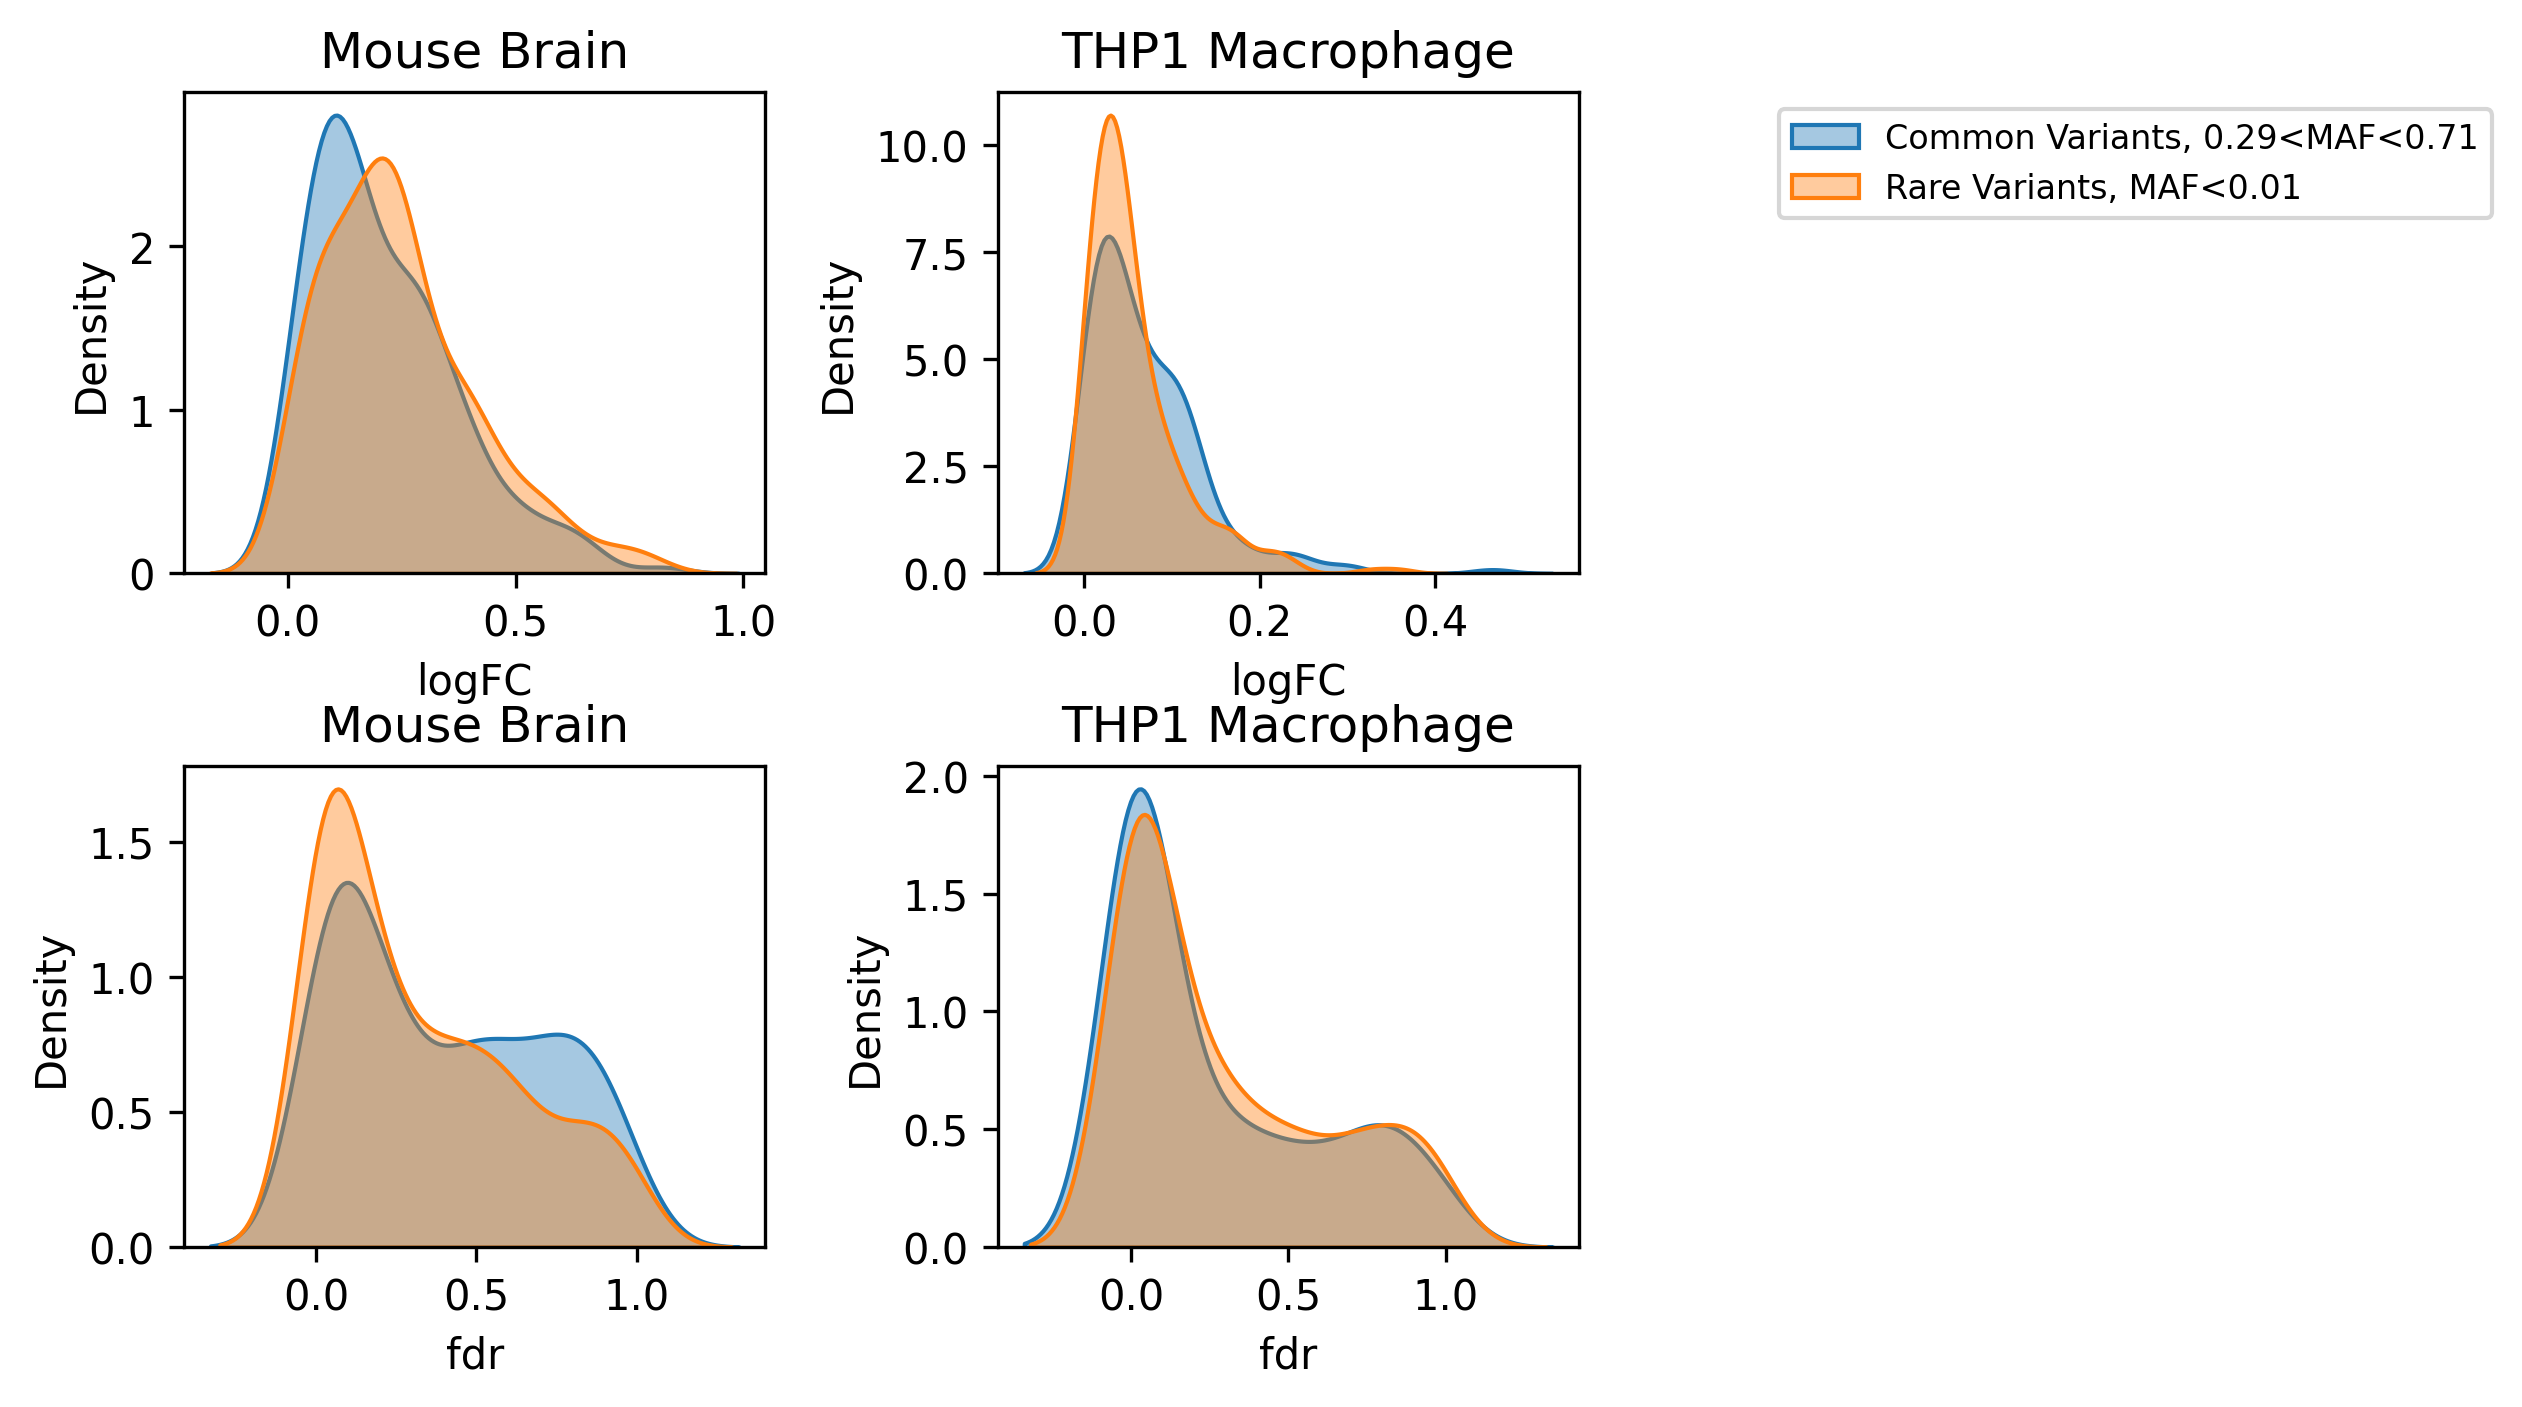

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# =========================================================
# 1. Load data
# =========================================================
df_allele_brain = pd.read_csv(
    "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
    index_col=0
)

df_allele_macrophage = pd.read_csv(
    "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",
    index_col=0
)

# =========================================================
# 2. Thresholds
# =========================================================
rare_low = 0.01
rare_high = 1 - rare_low
common_low = 0.29
common_high = 1 - common_low

df_merged_brain = df_allele_brain.copy()
df_merged_macrophage = df_allele_macrophage.copy()

# =========================================================
# 3. Helper function
# =========================================================
def extract_common_rare(df, value_col):
    common = df.loc[
        (df['EUR'] >= common_low) & (df['EUR'] <= common_high),
        value_col
    ].abs().dropna()

    rare = df.loc[
        (df['EUR'] < rare_low) | (df['EUR'] > rare_high),
        value_col
    ].abs().dropna()

    return common, rare

# =========================================================
# 4. Prepare data for plots and tests
# =========================================================
brain_common_logfc, brain_rare_logfc = extract_common_rare(df_merged_brain, 'logFC')
mac_common_logfc, mac_rare_logfc = extract_common_rare(df_merged_macrophage, 'logFC')

brain_common_fdr, brain_rare_fdr = extract_common_rare(df_merged_brain, 'fdr')
mac_common_fdr, mac_rare_fdr = extract_common_rare(df_merged_macrophage, 'fdr')

# =========================================================
# 5. Two Mann-Whitney U tests
# =========================================================
stat_mac, p_mac = mannwhitneyu(
    mac_common_logfc,
    mac_rare_logfc,
    alternative='greater'
)

stat_brain, p_brain = mannwhitneyu(
    brain_common_logfc,
    brain_rare_logfc,
    alternative='less'
)

# =========================================================
# 6. BH-FDR across the TWO tests only
# =========================================================
pvals = [p_mac, p_brain]
q_mac, q_brain = multipletests(pvals, method='fdr_bh')[1]

# =========================================================
# 7. Print results only
# =========================================================
print("=== Mann-Whitney U tests on |logFC| ===")
print(f"THP1 Macrophage statistic = {stat_mac:.6g}, raw p = {p_mac:.6g}, BH-FDR q = {q_mac:.6g}")
print(f"Mouse Brain      statistic = {stat_brain:.6g}, raw p = {p_brain:.6g}, BH-FDR q = {q_brain:.6g}")

print("\n=== Group sizes ===")
print(f"THP1 Macrophage: common = {len(mac_common_logfc)}, rare = {len(mac_rare_logfc)}")
print(f"Mouse Brain:     common = {len(brain_common_logfc)}, rare = {len(brain_rare_logfc)}")

# =========================================================
# 8. Plot
# =========================================================
fig, axs = plt.subplots(2, 2, figsize=(6, 5), dpi=300)

# Top-left: Absolute logFC for Brain
sns.kdeplot(brain_common_logfc, fill=True, alpha=0.4, ax=axs[0, 0])
sns.kdeplot(brain_rare_logfc, fill=True, alpha=0.4, ax=axs[0, 0])
axs[0, 0].set_title("Mouse Brain")
axs[0, 0].legend(
    [f"Common Variants, {common_low}<MAF<{common_high:.2f}",
     f"Rare Variants, MAF<{rare_low}"],
    loc='upper right',
    bbox_to_anchor=(4, 1),
    fontsize=8
)

# Bottom-left: variant-level FDR for Brain
sns.kdeplot(brain_common_fdr, fill=True, alpha=0.4, ax=axs[1, 0])
sns.kdeplot(brain_rare_fdr, fill=True, alpha=0.4, ax=axs[1, 0])
axs[1, 0].set_title("Mouse Brain")

# Top-right: Absolute logFC for Macrophage
sns.kdeplot(mac_common_logfc, fill=True, alpha=0.4, ax=axs[0, 1])
sns.kdeplot(mac_rare_logfc, fill=True, alpha=0.4, ax=axs[0, 1])
axs[0, 1].set_title("THP1 Macrophage")

# Bottom-right: variant-level FDR for Macrophage
sns.kdeplot(mac_common_fdr, fill=True, alpha=0.4, ax=axs[1, 1])
sns.kdeplot(mac_rare_fdr, fill=True, alpha=0.4, ax=axs[1, 1])
axs[1, 1].set_title("THP1 Macrophage")

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.tight_layout()
plt.savefig('common_rare_density_plot_new.pdf', format='pdf', dpi=300)
plt.show()

In [45]:
df_index_unique = df_index.drop_duplicates('RSID')
forward = 0.01
reverse = 1-forward
df_index_common = df_index_unique[(df_index_unique['EUR']>=0.05) & (df_index_unique['EUR']<=0.95)]
df_index_rare = df_index_unique[(df_index_unique['EUR']<0.01) | (df_index_unique['EUR']>0.99)]
df_index_low = df_index_unique[(df_index_unique['EUR']>=0.01) & (df_index_unique['EUR']<0.05)]

print('total',len(df_index_unique),'rare',len(df_index_rare),'common',len(df_index_common),'low',len(df_index_low),'sum',len(df_index_common)+len(df_index_low)+len(df_index_rare))

total 599 rare 175 common 307 low 105 sum 587


low:0.01,high:0.99 | Brain P-value: 0.076 THP1 P-value: 0.018 253 591 Mean P-value: 0.047
low:0.02,high:0.98 | Brain P-value: 0.081 THP1 P-value: 0.052 253 478 Mean P-value: 0.066
low:0.03,high:0.97 | Brain P-value: 0.064 THP1 P-value: 0.07 253 464 Mean P-value: 0.067
low:0.04,high:0.96 | Brain P-value: 0.059 THP1 P-value: 0.05 253 441 Mean P-value: 0.055
low:0.05,high:0.95 | Brain P-value: 0.066 THP1 P-value: 0.051 253 437 Mean P-value: 0.058
low:0.06,high:0.94 | Brain P-value: 0.06 THP1 P-value: 0.051 253 434 Mean P-value: 0.055
low:0.07,high:0.93 | Brain P-value: 0.06 THP1 P-value: 0.051 253 434 Mean P-value: 0.055
low:0.08,high:0.92 | Brain P-value: 0.048 THP1 P-value: 0.053 253 420 Mean P-value: 0.051
low:0.09,high:0.91 | Brain P-value: 0.051 THP1 P-value: 0.041 253 408 Mean P-value: 0.046
low:0.1,high:0.9 | Brain P-value: 0.051 THP1 P-value: 0.039 253 399 Mean P-value: 0.045
low:0.11,high:0.89 | Brain P-value: 0.046 THP1 P-value: 0.038 253 397 Mean P-value: 0.042
low:0.12,high:0.

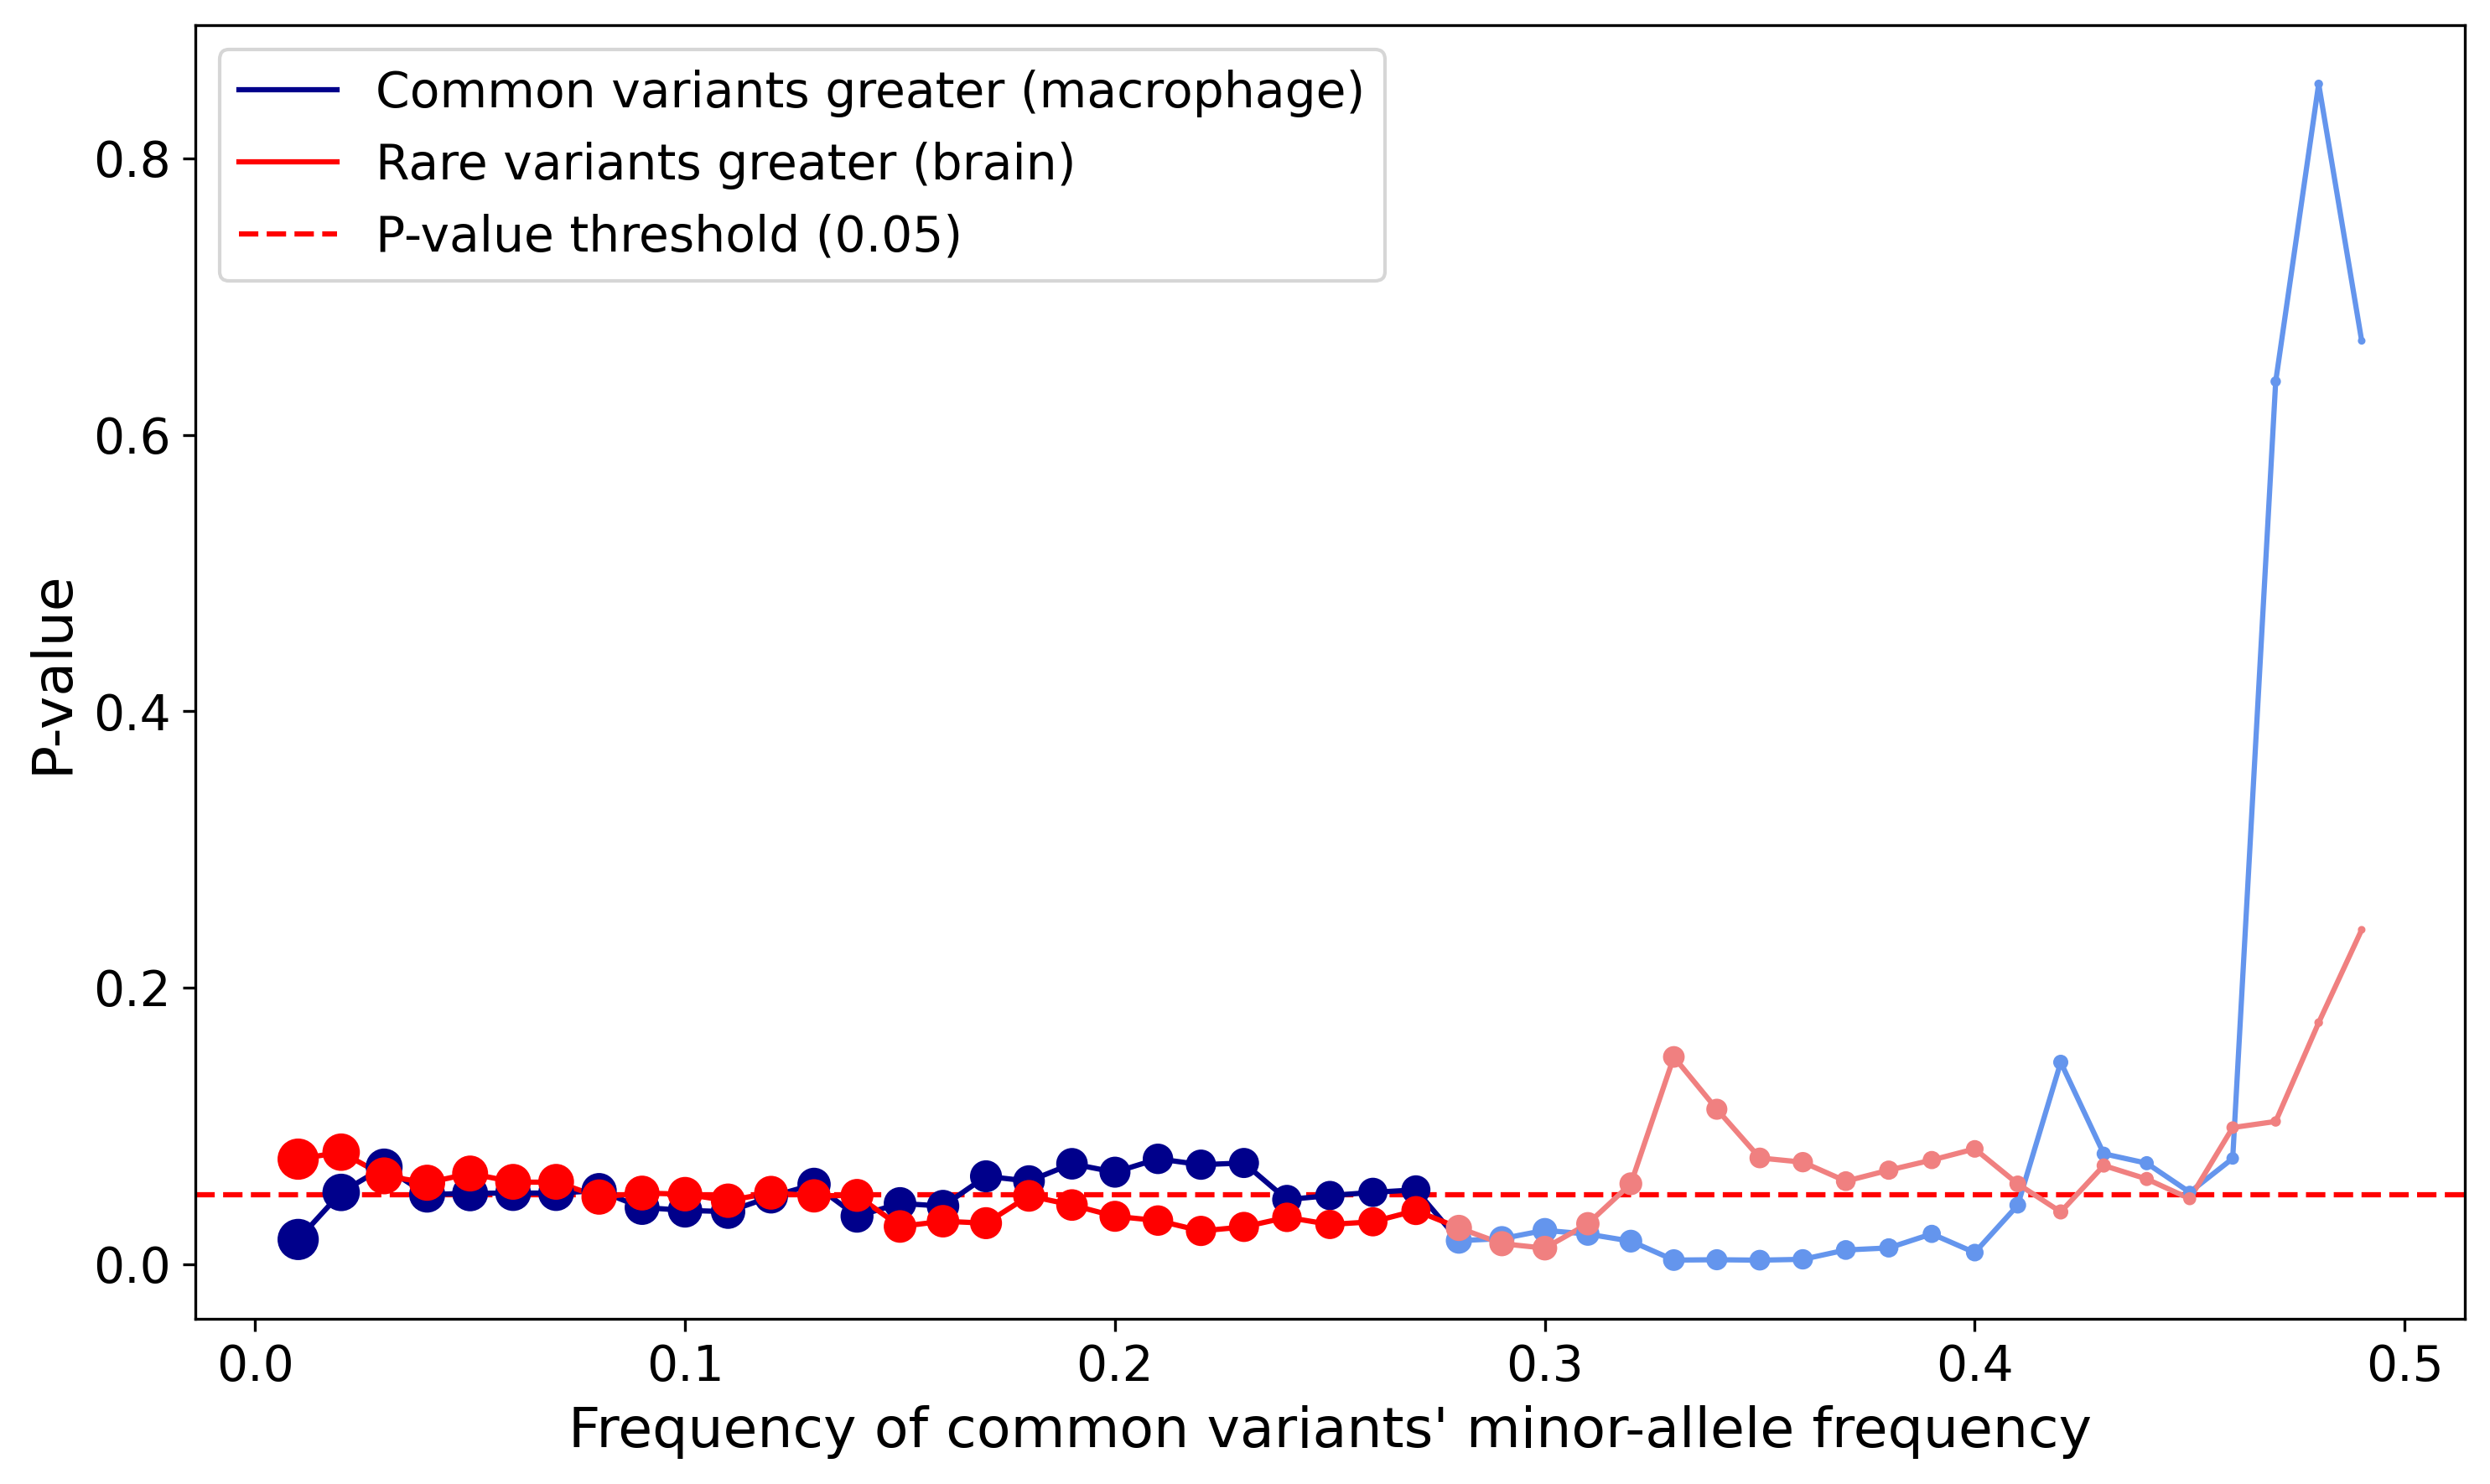

In [96]:
#Plot Common Variants vs Rare variants
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu
df_allele_brain = pd.read_csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv", index_col=0)
df_allele_macrophage = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv' , index_col=0)
df_index = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_20250617.csv',index_col=0)

df_merged_brain = df_allele_brain#[~df_allele_brain['RSID'].isin(RSID_exclude)]
df_merged_macrophage = df_allele_macrophage#[~df_allele_macrophage['RSID'].isin(RSID_exclude)]

import numpy as np
step = 0.01
low_values = np.arange(0.01, 0.5, step)
high_values = 1 - low_values

pairs = list(zip(low_values, high_values))
p_list = []
rare_threshold = 0.01
for i in pairs:
    low = round(i[0],2)
    high = round(i[1],2)

    rare_variants = abs(df_merged_macrophage[(df_merged_macrophage['EUR'] < rare_threshold)|(df_merged_macrophage['EUR'] > (1-rare_threshold))]['logFC'])
    common_variants = abs(df_merged_macrophage[(df_merged_macrophage['EUR']  >= low) & (df_merged_macrophage['EUR'] <= high)]['logFC'])

    import pandas as pd
    from scipy.stats import mannwhitneyu
    # Perform the Mann-Whitney U test
    statistic, p_value_mac = mannwhitneyu(common_variants, rare_variants, alternative='greater')
    
    #########################################################################
    rare_variants = abs(df_merged_brain[(df_merged_brain['EUR'] < rare_threshold)|(df_merged_brain['EUR'] > (1-rare_threshold))]['logFC'])
    common_variants = abs(df_merged_brain[(df_merged_brain['EUR']  >= low) & (df_merged_brain['EUR'] <= high)]['logFC'])

    # Perform the Mann-Whitney U test
    statistic, p_value_brain = mannwhitneyu(common_variants, rare_variants, alternative='less')
    p_list.append([low,high,p_value_mac,p_value_brain,len(common_variants)/len(rare_variants)])
    print(f'low:{round(low,3)},high:{round(high,3)}',"|",f'Brain P-value: {round(p_value_brain,3)}',f'THP1 P-value: {round(p_value_mac,3)}',len(rare_variants),len(common_variants),f'Mean P-value: {round((p_value_brain+p_value_mac)/2,3)}')
    #if low == 0.29:
        #common_variants_29 = common_variants
        #break
import matplotlib.pyplot as plt


# Provided data
data = p_list
# Extract x, y1, and y2 values
x_values = [row[0] for row in data]
y1_values = [row[2] for row in data]
y2_values = [row[3] for row in data]
ratio_common_rare = [np.log(row[4])for row in data]
ratio_common_rare_normalized= [row[4]*50 for row in data]
# Determining colors based on positive or negative values of ratio_common_rare
colors_y1 = ['darkblue' if value > 0 else 'cornflowerblue' for value in ratio_common_rare]  # 'cornflowerblue' as a mid-tone blue color

# Adjusting the colors to use light red instead of orange for negative values in y2

colors_y2 = ['red' if value > 0 else 'lightcoral' for value in ratio_common_rare]  # 'lightcoral' as a light red color

# Replotting with updated color
plt.figure(figsize=(10, 6),dpi=300)
# --- plot the blue (macrophage) curve first, low zorder -----------
for i in range(len(x_values) - 1):
    plt.plot(x_values[i:i+2], y1_values[i:i+2],
             color=colors_y1[i], zorder=1,
             label="Common variants greater (macrophage)" if i == 0 else None)

# --- plot the red (brain) curve afterwards, higher zorder ----------
for i in range(len(x_values) - 1):
    plt.plot(x_values[i:i+2], y2_values[i:i+2],
             color=colors_y2[i], zorder=2,
             label="Rare variants greater (brain)" if i == 0 else None)

# --- scatter: blue first (low), red second (high) ------------------
plt.scatter(x_values, y1_values,
            s=ratio_common_rare_normalized,
            color=colors_y1, alpha=1, zorder=2)          # below red dots

plt.scatter(x_values, y2_values,
            s=ratio_common_rare_normalized,
            color=colors_y2, alpha=1, zorder=3)          # on top of blue dots

# optional: make the dashed cut-off line label readable too
plt.axhline(y=0.05, color='red', linestyle='--',
            label='P-value threshold (0.05)',
            zorder=0)


# --- axis labels ---------------------------------------------------
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Frequency of common variants' minor-allele frequency", fontsize=16)
plt.ylabel("P-value", fontsize=16)
plt.legend(fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.savefig('common_rare_p_plot_new.pdf', format='pdf',dpi=300)
plt.show()







low:0.01, high:0.99 | Brain raw p: 0.07592 | THP1 raw p: 0.01781
low:0.02, high:0.98 | Brain raw p: 0.08098 | THP1 raw p: 0.05185
low:0.03, high:0.97 | Brain raw p: 0.06383 | THP1 raw p: 0.07024
low:0.04, high:0.96 | Brain raw p: 0.05885 | THP1 raw p: 0.0503
low:0.05, high:0.95 | Brain raw p: 0.06552 | THP1 raw p: 0.05121
low:0.06, high:0.94 | Brain raw p: 0.0595 | THP1 raw p: 0.05139
low:0.07, high:0.93 | Brain raw p: 0.0595 | THP1 raw p: 0.05139
low:0.08, high:0.92 | Brain raw p: 0.04849 | THP1 raw p: 0.05311
low:0.09, high:0.91 | Brain raw p: 0.05138 | THP1 raw p: 0.04096
low:0.10, high:0.90 | Brain raw p: 0.05058 | THP1 raw p: 0.03888
low:0.11, high:0.89 | Brain raw p: 0.04584 | THP1 raw p: 0.03793
low:0.12, high:0.88 | Brain raw p: 0.05161 | THP1 raw p: 0.04882
low:0.13, high:0.87 | Brain raw p: 0.04936 | THP1 raw p: 0.05765
low:0.14, high:0.86 | Brain raw p: 0.04968 | THP1 raw p: 0.03464
low:0.15, high:0.85 | Brain raw p: 0.02721 | THP1 raw p: 0.04391
low:0.16, high:0.84 | Brain 

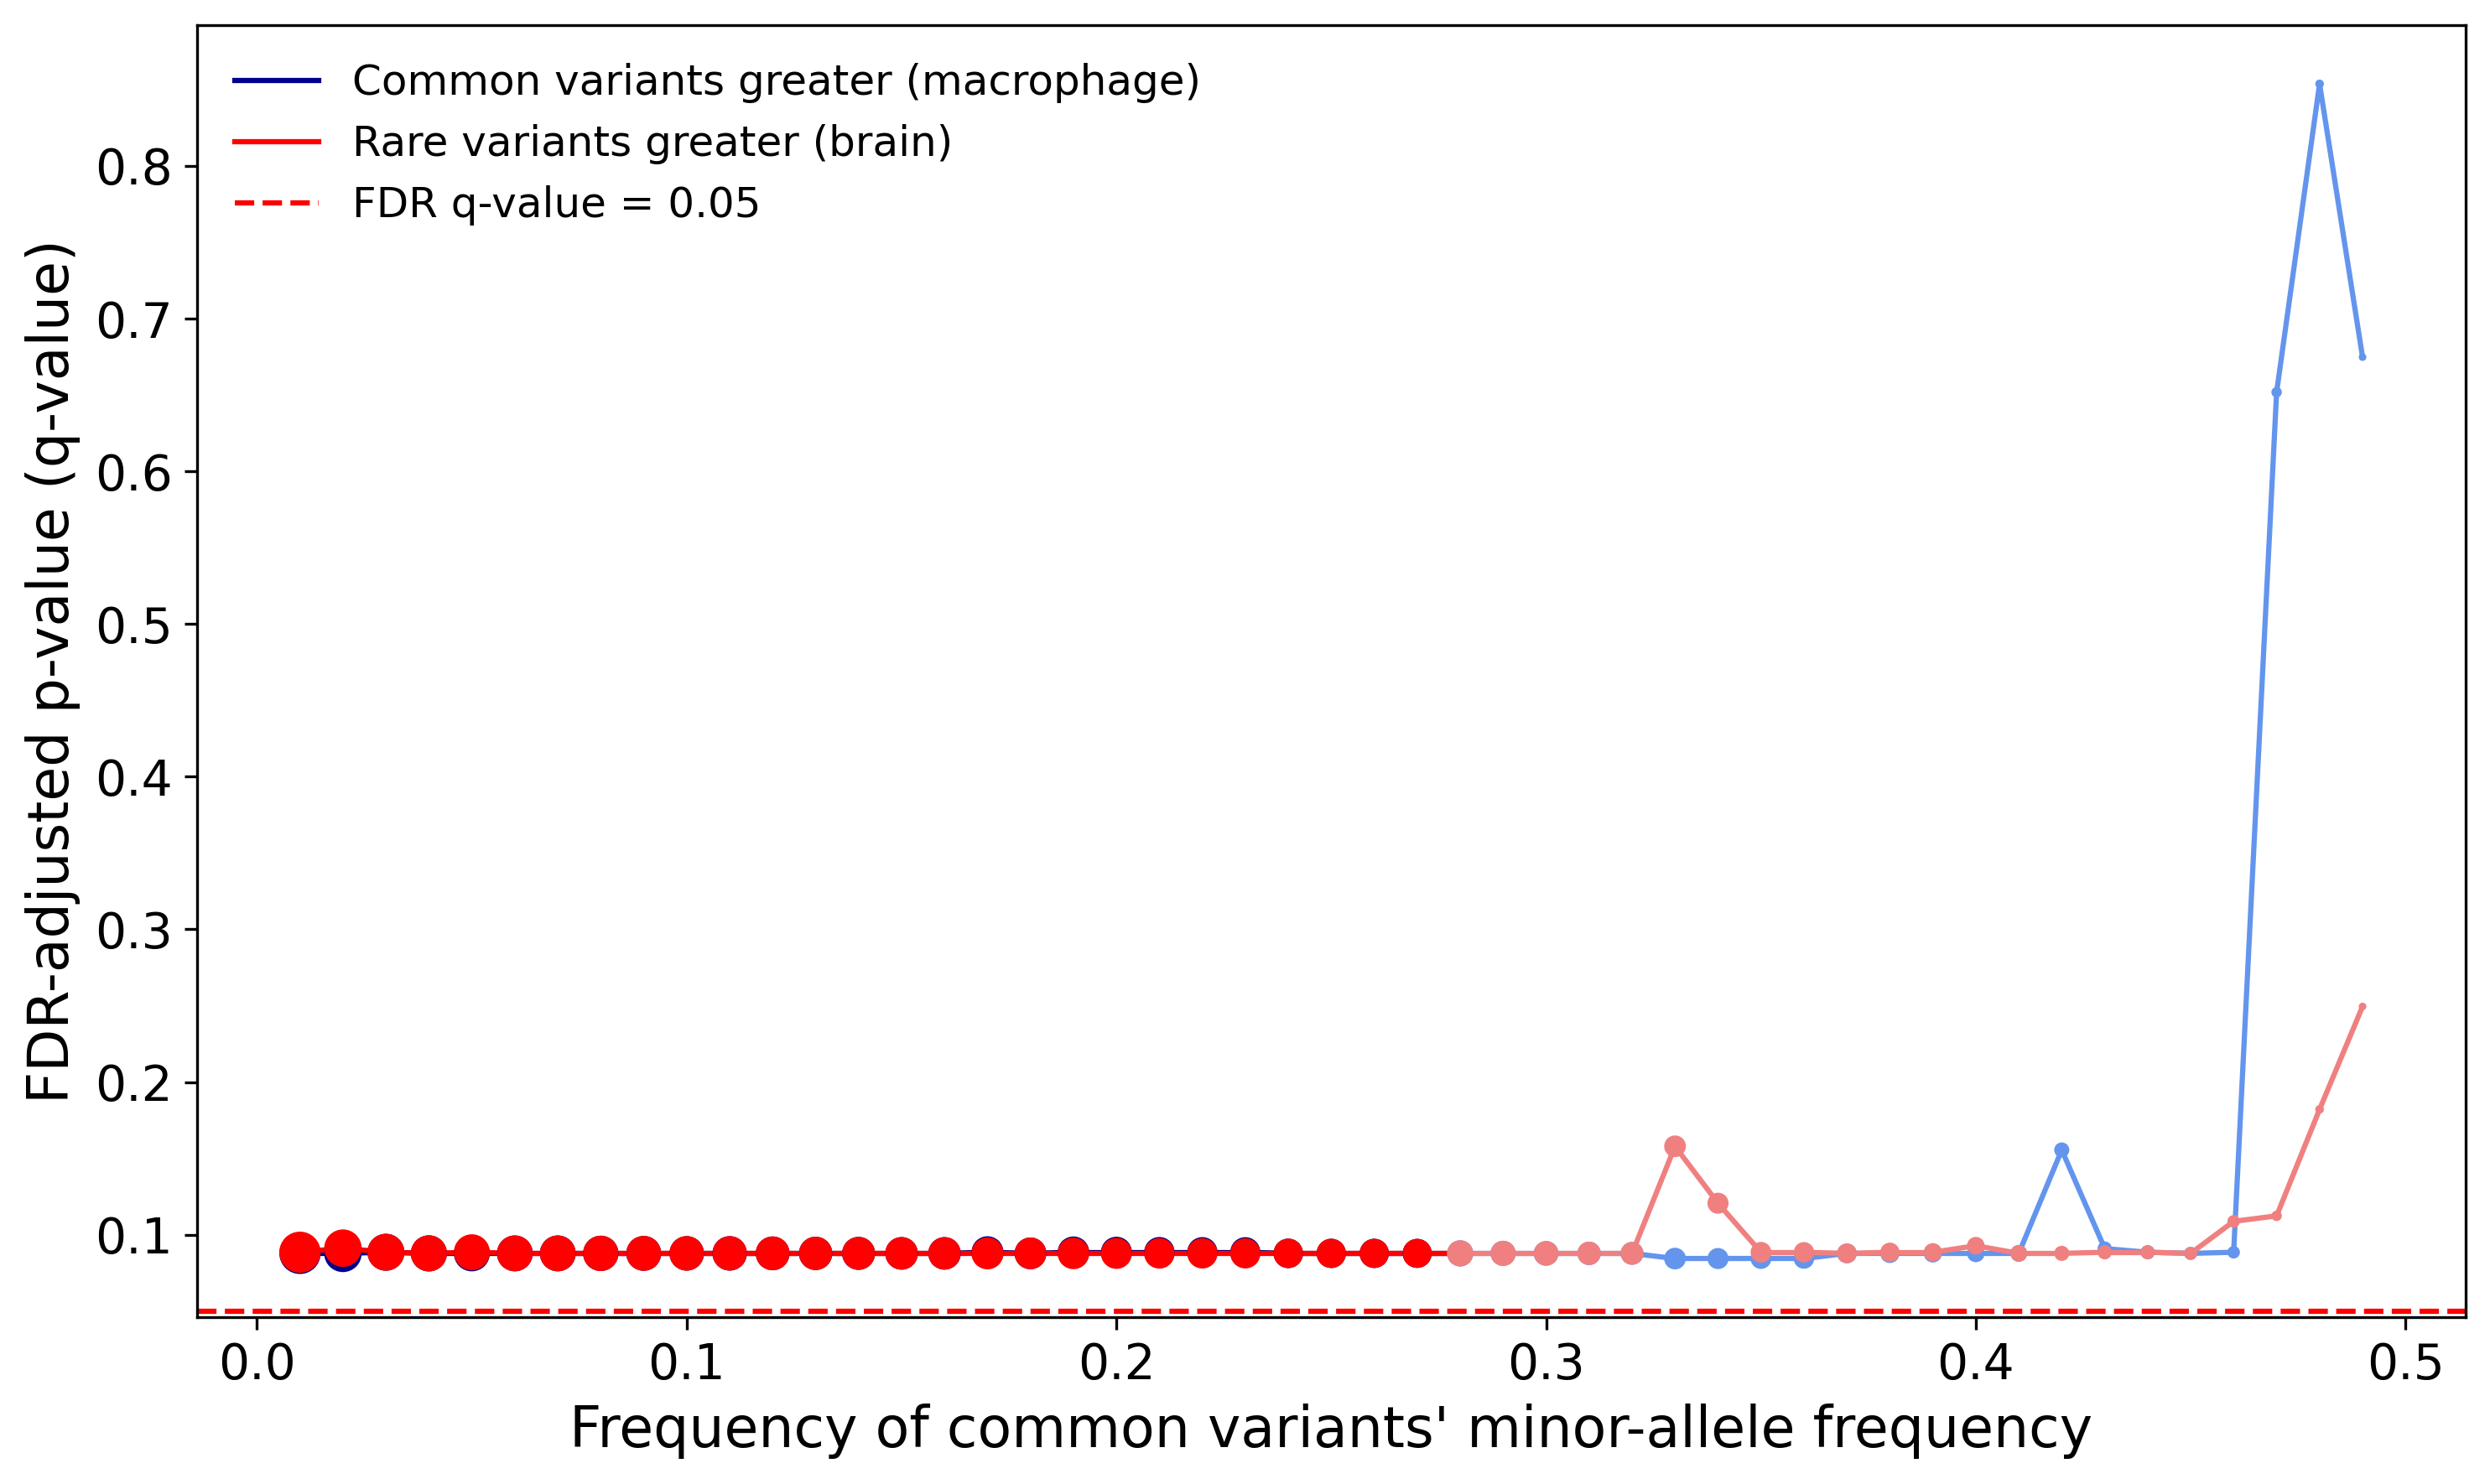


Macrophage FDR-significant rows:
Empty DataFrame
Columns: [low, high, p_mac, q_mac, n_common_mac, n_rare_mac]
Index: []

Brain FDR-significant rows:
Empty DataFrame
Columns: [low, high, p_brain, q_brain, n_common_brain, n_rare_brain]
Index: []


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# =========================================================
# 1. Read data
# =========================================================
df_allele_brain = pd.read_csv(
    "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
    index_col=0
)

df_allele_macrophage = pd.read_csv(
    "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",
    index_col=0
)

df_index = pd.read_csv(
    "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_20250617.csv",
    index_col=0
)

df_merged_brain = df_allele_brain.copy()
df_merged_macrophage = df_allele_macrophage.copy()

# =========================================================
# 2. Settings
# =========================================================
step = 0.01
rare_threshold = 0.01

low_values = np.arange(0.01, 0.5, step)
high_values = 1 - low_values
pairs = list(zip(low_values, high_values))

# =========================================================
# 3. Helper function
# =========================================================
def safe_mannwhitneyu(x, y, alternative='two-sided'):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()

    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan

    stat, p = mannwhitneyu(x, y, alternative=alternative)
    return stat, p

# =========================================================
# 4. Scan thresholds
# =========================================================
results = []

for low_raw, high_raw in pairs:
    low = round(low_raw, 2)
    high = round(high_raw, 2)

    # -------------------------
    # Macrophage: common > rare
    # -------------------------
    rare_mac = abs(
        df_merged_macrophage[
            (df_merged_macrophage['EUR'] < rare_threshold) |
            (df_merged_macrophage['EUR'] > (1 - rare_threshold))
        ]['logFC']
    )

    common_mac = abs(
        df_merged_macrophage[
            (df_merged_macrophage['EUR'] >= low) &
            (df_merged_macrophage['EUR'] <= high)
        ]['logFC']
    )

    stat_mac, p_mac = safe_mannwhitneyu(
        common_mac,
        rare_mac,
        alternative='greater'
    )

    # -------------------------
    # Brain: rare > common
    # so test common < rare
    # -------------------------
    rare_brain = abs(
        df_merged_brain[
            (df_merged_brain['EUR'] < rare_threshold) |
            (df_merged_brain['EUR'] > (1 - rare_threshold))
        ]['logFC']
    )

    common_brain = abs(
        df_merged_brain[
            (df_merged_brain['EUR'] >= low) &
            (df_merged_brain['EUR'] <= high)
        ]['logFC']
    )

    stat_brain, p_brain = safe_mannwhitneyu(
        common_brain,
        rare_brain,
        alternative='less'
    )

    ratio = np.nan
    if len(rare_mac) > 0:
        ratio = len(common_mac) / len(rare_mac)

    results.append([
        low,
        high,
        stat_mac,
        p_mac,
        stat_brain,
        p_brain,
        len(rare_mac),
        len(common_mac),
        len(rare_brain),
        len(common_brain),
        ratio
    ])

    print(
        f"low:{low:.2f}, high:{high:.2f} | "
        f"Brain raw p: {p_brain:.4g} | "
        f"THP1 raw p: {p_mac:.4g}"
    )

# =========================================================
# 5. Build result table
# =========================================================
df_res = pd.DataFrame(
    results,
    columns=[
        'low', 'high',
        'stat_mac', 'p_mac',
        'stat_brain', 'p_brain',
        'n_rare_mac', 'n_common_mac',
        'n_rare_brain', 'n_common_brain',
        'ratio_common_to_rare'
    ]
)

# =========================================================
# 6. Global BH-FDR across both cell types
# =========================================================
all_tests = pd.concat([
    df_res[['low', 'high', 'p_mac']].rename(columns={'p_mac': 'p'}).assign(celltype='Macrophage'),
    df_res[['low', 'high', 'p_brain']].rename(columns={'p_brain': 'p'}).assign(celltype='Brain')
], ignore_index=True)

all_tests['q'] = np.nan
valid_mask = all_tests['p'].notna()

all_tests.loc[valid_mask, 'q'] = multipletests(
    all_tests.loc[valid_mask, 'p'],
    method='fdr_bh'
)[1]

df_mac_q = (
    all_tests[all_tests['celltype'] == 'Macrophage'][['low', 'high', 'q']]
    .rename(columns={'q': 'q_mac'})
    .reset_index(drop=True)
)

df_brain_q = (
    all_tests[all_tests['celltype'] == 'Brain'][['low', 'high', 'q']]
    .rename(columns={'q': 'q_brain'})
    .reset_index(drop=True)
)

df_res = pd.concat(
    [df_res.reset_index(drop=True), df_mac_q[['q_mac']], df_brain_q[['q_brain']]],
    axis=1
)

df_res['sig_mac_fdr'] = df_res['q_mac'] < 0.05
df_res['sig_brain_fdr'] = df_res['q_brain'] < 0.05

df_res.to_csv("common_rare_scan_results_with_qvalues.csv", index=False)

# =========================================================
# 7. Plot directly using q-values
# =========================================================
x_values = df_res['low'].tolist()
y1_values = df_res['q_mac'].tolist()
y2_values = df_res['q_brain'].tolist()

ratio_common_rare = np.log(df_res['ratio_common_to_rare'].replace(0, np.nan))
ratio_common_rare = ratio_common_rare.fillna(0)

ratio_common_rare_normalized = df_res['ratio_common_to_rare'].fillna(0) * 50

colors_y1 = ['darkblue' if value > 0 else 'cornflowerblue' for value in ratio_common_rare]
colors_y2 = ['red' if value > 0 else 'lightcoral' for value in ratio_common_rare]

plt.figure(figsize=(10, 6), dpi=300)

# macrophage line first
for i in range(len(x_values) - 1):
    plt.plot(
        x_values[i:i+2],
        y1_values[i:i+2],
        color=colors_y1[i],
        zorder=1,
        label="Common variants greater (macrophage)" if i == 0 else None
    )

# brain line second
for i in range(len(x_values) - 1):
    plt.plot(
        x_values[i:i+2],
        y2_values[i:i+2],
        color=colors_y2[i],
        zorder=2,
        label="Rare variants greater (brain)" if i == 0 else None
    )

# macrophage points
plt.scatter(
    x_values,
    y1_values,
    s=ratio_common_rare_normalized,
    color=colors_y1,
    alpha=1,
    zorder=2
)

# brain points
plt.scatter(
    x_values,
    y2_values,
    s=ratio_common_rare_normalized,
    color=colors_y2,
    alpha=1,
    zorder=3
)

# q-value threshold
plt.axhline(
    y=0.05,
    color='red',
    linestyle='--',
    label='FDR q-value = 0.05',
    zorder=0
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Frequency of common variants' minor-allele frequency", fontsize=16)
plt.ylabel("FDR-adjusted p-value (q-value)", fontsize=16)
plt.legend(fontsize=12, frameon=False)
plt.grid(False)
plt.tight_layout()

plt.savefig("common_rare_qvalue_plot.pdf", format="pdf", dpi=300)
plt.show()

# =========================================================
# 8. Print significant rows
# =========================================================
print("\nMacrophage FDR-significant rows:")
print(
    df_res.loc[
        df_res['sig_mac_fdr'],
        ['low', 'high', 'p_mac', 'q_mac', 'n_common_mac', 'n_rare_mac']
    ]
)

print("\nBrain FDR-significant rows:")
print(
    df_res.loc[
        df_res['sig_brain_fdr'],
        ['low', 'high', 'p_brain', 'q_brain', 'n_common_brain', 'n_rare_brain']
    ]
)

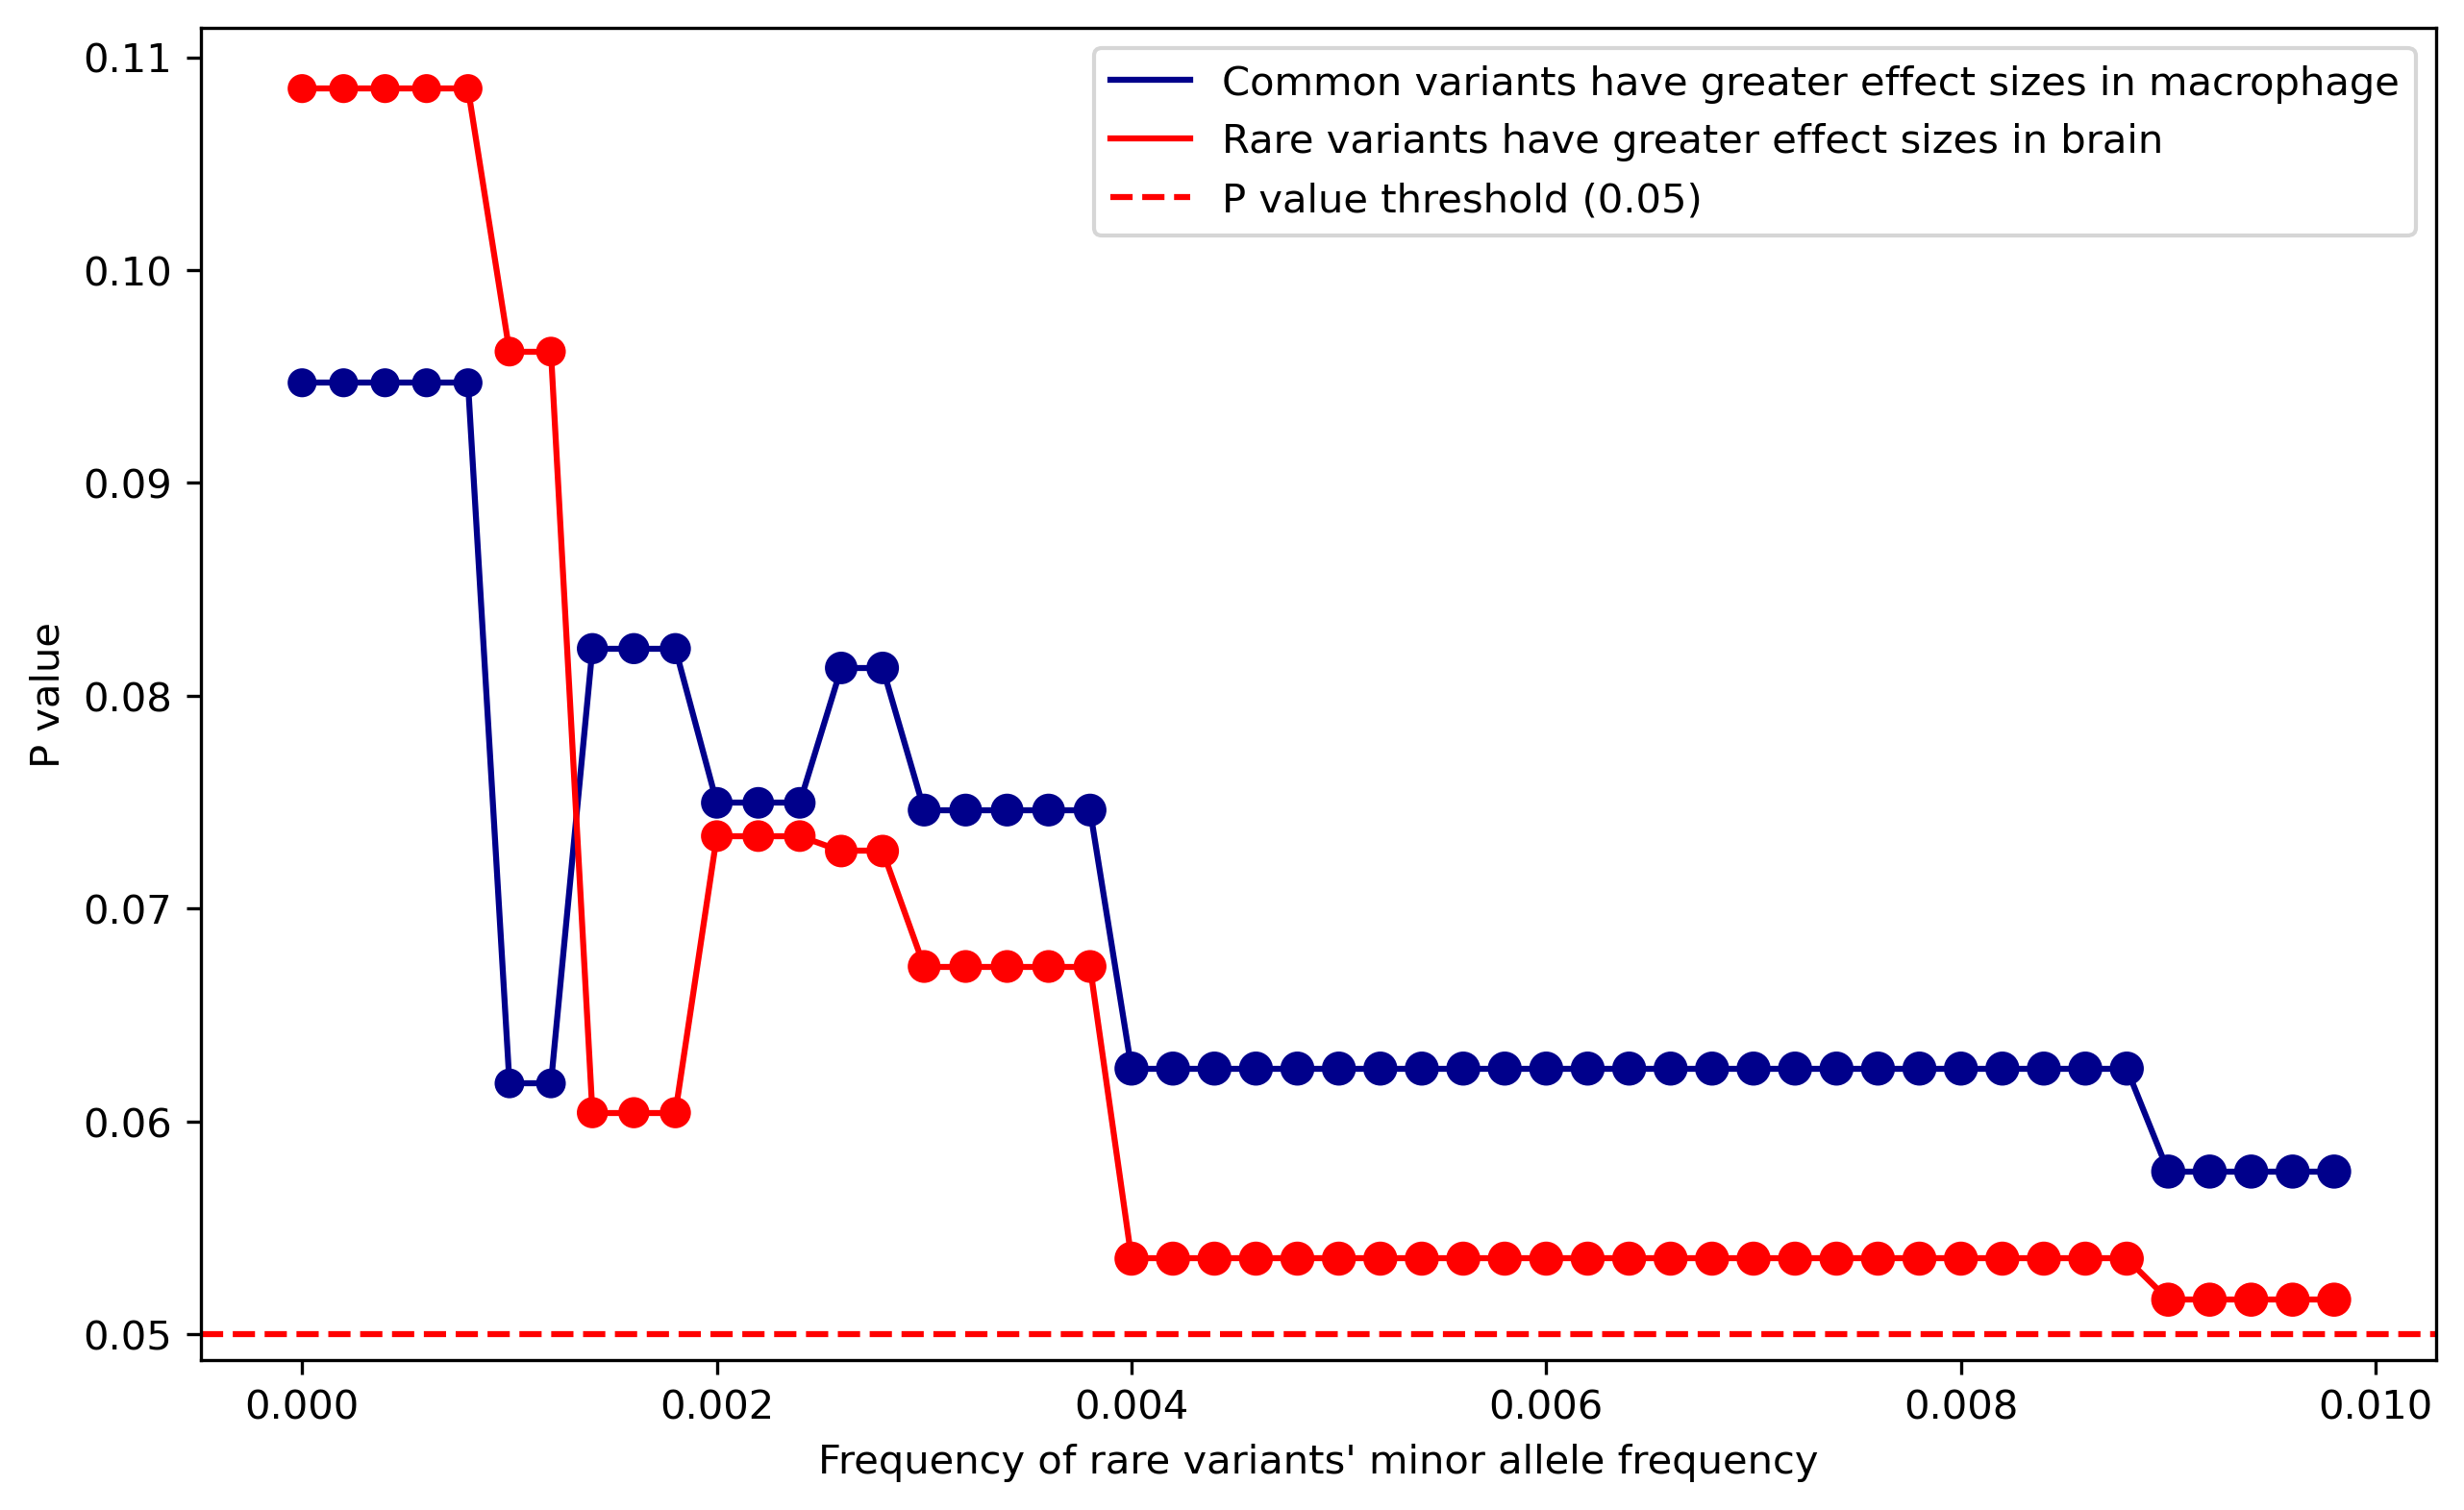

In [113]:
#Plot Common Variants vs Rare variants
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu
df_allele_brain = pd.read_csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv", index_col=0)
df_allele_macrophage = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv' , index_col=0)
df_index = pd.read_csv('indexing/SNP_haploreg_annotated_20240604.csv',index_col=0)

df_merged_brain = df_allele_brain
df_merged_macrophage = df_allele_macrophage

import numpy as np

low_values_rare = np.arange(0.0000000001, 0.01,  0.0002)
high_values_rare = 1 - low_values_rare

pairs = list(zip(low_values_rare, high_values_rare))
p_list = []
low = 0.37
high = 1-low
for i in pairs:
    low_rare = i[0]
    high_rare = i[1]
    rare_variants = abs(df_merged_macrophage[(df_merged_brain['EUR'] < low_rare)|(df_merged_brain['EUR'] > high_rare)]['logFC'])
    common_variants = abs(df_merged_macrophage[(df_merged_macrophage['EUR']  > low) & (df_merged_macrophage['EUR'] < high)]['logFC'])
    import pandas as pd
    from scipy.stats import mannwhitneyu
    # Perform the Mann-Whitney U test
    statistic, p_value_mac = mannwhitneyu(common_variants, rare_variants, alternative='greater')
    #print)
    
    #########################################################################
    rare_variants = abs(df_merged_brain[(df_merged_brain['EUR'] < low_rare)|(df_merged_brain['EUR'] > high_rare)]['logFC'])
    common_variants = abs(df_merged_brain[(df_merged_brain['EUR']  > low) & (df_merged_brain['EUR'] < high)]['logFC'])

    # Perform the Mann-Whitney U test
    statistic, p_value_brain = mannwhitneyu(common_variants, rare_variants, alternative='less')
    p_list.append([low_rare,high_rare,p_value_mac,p_value_brain,len(rare_variants)/len(common_variants)])
    #print(f'low:{round(low,2)},high:{round(high,2)}',"|",f'Brain P-value: {round(p_value_brain,2)}',f'THP1 P-value: {round(p_value_mac,2)}',len(rare_variants),len(common_variants))

import matplotlib.pyplot as plt

# Provided data
data = p_list
# Extract x, y1, and y2 values
x_values = [row[0] for row in data]
y1_values = [row[2] for row in data]
y2_values = [row[3] for row in data]
ratio_common_rare = [row[4] for row in data]
ratio_common_rare_normalized= [row[4]*20 for row in data]
# Determining colors based on positive or negative values of ratio_common_rare
colors_y1 = ['darkblue' if value > 1 else 'cornflowerblue' for value in ratio_common_rare]  # 'cornflowerblue' as a mid-tone blue color

# Adjusting the colors to use light red instead of orange for negative values in y2

colors_y2 = ['red' if value > 1 else 'lightcoral' for value in ratio_common_rare]  # 'lightcoral' as a light red color

# Replotting with updated color

plt.figure(figsize=(10, 6),dpi=300)

# Plotting the curves by segments to match the scatter colors, using labels for legend
for i in range(len(x_values) - 1):
    if i == 0:
        plt.plot(x_values[i:i+2], y1_values[i:i+2], color=colors_y1[i], label="Common variants have greater effect sizes in macrophage")
        plt.plot(x_values[i:i+2], y2_values[i:i+2], color=colors_y2[i], label="Rare variants have greater effect sizes in brain")
    else:
        plt.plot(x_values[i:i+2], y1_values[i:i+2], color=colors_y1[i])
        plt.plot(x_values[i:i+2], y2_values[i:i+2], color=colors_y2[i])

# Scatter plot with color differentiation based on positive or negative ratio_common_rare
plt.scatter(x_values, y2_values, s=ratio_common_rare_normalized, color=colors_y2, alpha=1)
plt.scatter(x_values, y1_values, s=ratio_common_rare_normalized, color=colors_y1, alpha=1)


plt.axhline(y=0.05, color='red', linestyle='--', label='P value threshold (0.05)')
plt.xlabel("Frequency of rare variants' minor allele frequency")
plt.ylabel("P value")
#plt.title("Curve Plot for Macrophage and Brain with Matching Line and Dot Colors")
plt.legend()
plt.grid(False)
plt.show()




In [100]:
import numpy as np

p_values = np.array([0.03, 0.09])
ranks = np.argsort(p_values) + 1  # ranks starting from 1
m = len(p_values)
Q = 0.05

# Calculate critical values
critical_values = (ranks / m) * Q

# Calculate adjusted p-values (Benjamini-Hochberg)
adjusted_p_values = np.empty(m)
adjusted_p_values[-1] = p_values[ranks[-1] - 1]
for i in range(m - 2, -1, -1):
    adjusted_p_values[i] = min(p_values[ranks[i] - 1], adjusted_p_values[i + 1])

# Resulting adjusted p-values
print("Adjusted P-values:", adjusted_p_values)


Adjusted P-values: [0.03 0.09]


In [89]:
rare_variants_mac_zscore = (rare_variants_mac - rare_variants_mac.mean()) / rare_variants_mac.std()
common_variants_mac_zscore = (common_variants_mac - common_variants_mac.mean()) / common_variants_mac.std()
rare_variants_brain_zscore = (rare_variants_brain - rare_variants_brain.mean()) / rare_variants_brain.std()
common_variants_brain_zscore = (common_variants_brain - common_variants_brain.mean()) / common_variants_brain.std()


Wilcoxon Signed-Rank Test Statistic: 6521.0, P-value: 0.788368358723642
No significant difference between brain and macrophage effects for rare variants.


In [98]:
import numpy as np
from scipy.stats import wilcoxon

# Calculate differences for determining the direction
differences = -common_variants_brain_zscore + common_variants_mac_zscore

# Performing the Wilcoxon Signed-Rank test
stat, p_value = wilcoxon(differences)

# Adjust for a one-tailed test if the median difference is positive
if np.median(differences) > 0:
    one_tailed_p_value = p_value / 2
else:
    # If median is negative and your hypothesis is that brain > macrophage, you should not halve the p-value
    one_tailed_p_value = 1 - (p_value / 2)

# Output the results
print(f"Wilcoxon Signed-Rank Test Statistic: {stat}, One-Tailed P-value: {one_tailed_p_value}")

# Interpretation based on p-value
if one_tailed_p_value < 0.05:
    print("Significant difference in the hypothesized direction.")
else:
    print("No significant difference in the hypothesized direction.")

Wilcoxon Signed-Rank Test Statistic: 6618.0, One-Tailed P-value: 0.5953610425215558
No significant difference in the hypothesized direction.


Adjusted P-values: [0.03 0.09]


In [97]:
import numpy as np
from scipy.stats import wilcoxon

# Calculate differences for determining the direction
differences = rare_variants_brain_zscore - rare_variants_mac_zscore

# Performing the Wilcoxon Signed-Rank test
stat, p_value = wilcoxon(differences)

# Adjust for a one-tailed test if the median difference is positive
if np.median(differences) > 0:
    one_tailed_p_value = p_value / 2
else:
    # If median is negative and your hypothesis is that brain > macrophage, you should not halve the p-value
    one_tailed_p_value = 1 - (p_value / 2)

# Output the results
print(f"Wilcoxon Signed-Rank Test Statistic: {stat}, One-Tailed P-value: {one_tailed_p_value}")

# Interpretation based on p-value
if one_tailed_p_value < 0.05:
    print("Significant difference in the hypothesized direction.")
else:
    print("No significant difference in the hypothesized direction.")

Wilcoxon Signed-Rank Test Statistic: 6521.0, One-Tailed P-value: 0.394184179361821
No significant difference in the hypothesized direction.


# ML Common vs Rare

In [ ]:
df_cluster = pd.read_csv( ('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/majorminor_logfc.csv'),index_col=0)
#df_cluster =  all_shap_effect
df_index = pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv",index_col=0)
#df_cluster['Rare_Common'] = df_index['Rare_Common']
df_cluster['EUR'] = df_index['EUR']
df_cluster_rare = df_cluster[df_cluster['EUR']<0.01]
df_cluster_common = df_cluster[df_cluster['EUR']>0.35]
import pandas as pd

mouse_rare = df_cluster_rare['Mouse_Cortex_AgeB-model'].abs().tolist()#+df_cluster_rare['Mouse_Cortex_AgeC'].abs().tolist() +df_cluster_rare['Mouse_Striatum_AgeB'].abs().tolist()+df_cluster_rare['Mouse_Striatum_AgeC'].abs().tolist()
mouse_common = df_cluster_common['Mouse_Cortex_AgeB-model'].abs().tolist()#+df_cluster_common['Mouse_Cortex_AgeC'].abs().tolist() +df_cluster_common['Mouse_Striatum_AgeB'].abs().tolist()+df_cluster_common['Mouse_Striatum_AgeC'].abs().tolist()
thp1_rare = df_cluster_rare['THP1_Naive-Calvin'].abs().tolist()#+df_cluster_rare['THP1_Macrophage_IFNB'].abs().tolist() +df_cluster_rare['THP1_Macrophage_IFNG'].abs().tolist()+df_cluster_rare['THP1_Macrophage_LPSIFNG'].abs().tolist()
thp1_common = df_cluster_common['THP1_Naive-Calvin'].abs().tolist()#+df_cluster_common['THP1_Macrophage_IFNB'].abs().tolist() +df_cluster_common['THP1_Macrophage_IFNG'].abs().tolist()+df_cluster_common['THP1_Macrophage_LPSIFNG'].abs().tolist()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots
fig, axs = plt.subplots(2, figsize=(6, 5), dpi=300)

# First subplot for mouse data
sns.kdeplot(mouse_rare, fill=True, alpha=0.4, ax=axs[0], label='Mouse Rare')
sns.kdeplot(mouse_common, fill=True, alpha=0.4, ax=axs[0], label='Mouse Common')
axs[0].legend()  # Add legend to the first subplot

# Second subplot for THP1 data
sns.kdeplot(thp1_rare, fill=True, alpha=0.4, ax=axs[1], label='THP1 Rare')
sns.kdeplot(thp1_common, fill=True, alpha=0.4, ax=axs[1], label='THP1 Common')
axs[1].legend()  # Add legend to the second subplot

# Optionally, display the plot
plt.show()

In [ ]:
df_index = pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_20250617.csv",index_col=0)